100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]


Epoch 1/8  Train MSE: 0.055958  Test MSE: 0.025789
Epoch 2/8  Train MSE: 0.022168  Test MSE: 0.018943
Epoch 3/8  Train MSE: 0.018041  Test MSE: 0.016589
Epoch 4/8  Train MSE: 0.016296  Test MSE: 0.015252
Epoch 5/8  Train MSE: 0.015249  Test MSE: 0.014516
Epoch 6/8  Train MSE: 0.014559  Test MSE: 0.013930
Epoch 7/8  Train MSE: 0.014039  Test MSE: 0.013474
Epoch 8/8  Train MSE: 0.013658  Test MSE: 0.013159


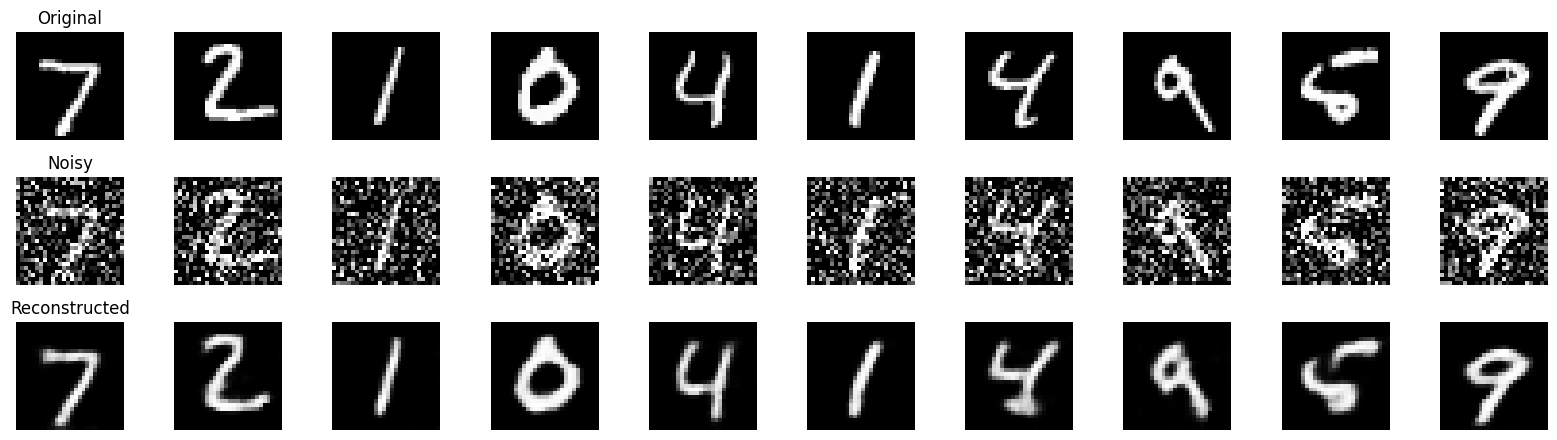

In [1]:
# simple_denoising_autoencoder.py
# Requirements: torch torchvision matplotlib
# pip install torch torchvision matplotlib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

# ---------------- config ----------------
SEED = 42
BATCH = 128
EPOCHS = 8
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NOISE_STD = 0.5   # gaussian noise level

random.seed(SEED)
torch.manual_seed(SEED)

# ---------------- data ----------------
transform = transforms.Compose([
    transforms.ToTensor(),             # converts to [0,1]
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

# helper to add gaussian noise and clip to [0,1]
def add_noise(x, std=NOISE_STD):
    noise = torch.randn_like(x) * std
    nx = x + noise
    return torch.clip(nx, 0.0, 1.0)

# ---------------- model: small conv autoencoder ----------------
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU(True),
            nn.Flatten(),
            nn.Linear(32*7*7, latent_dim),
            nn.ReLU(True),
        )
        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 32*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (32,7,7)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 7->14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 14->28
            nn.Sigmoid(),  # to [0,1]
        )

    def forward(self, x):
        z = self.enc(x)
        out = self.dec(z)
        return out

model = ConvAutoencoder(latent_dim=64).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# ---------------- training loop ----------------
def train_epoch():
    model.train()
    total_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE)
        noisy = add_noise(imgs)
        recon = model(noisy)
        loss = criterion(recon, imgs)   # compare to clean images
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(train_loader.dataset)

def evaluate():
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(DEVICE)
            noisy = add_noise(imgs)
            recon = model(noisy)
            loss = criterion(recon, imgs)
            total_loss += loss.item() * imgs.size(0)
    return total_loss / len(test_loader.dataset)

for ep in range(1, EPOCHS+1):
    tr = train_epoch()
    te = evaluate()
    print(f"Epoch {ep}/{EPOCHS}  Train MSE: {tr:.6f}  Test MSE: {te:.6f}")

# ---------------- visualize results ----------------
def show_reconstructions(n=8):
    model.eval()
    imgs, _ = next(iter(test_loader))
    imgs = imgs[:n].to(DEVICE)
    noisy = add_noise(imgs)
    with torch.no_grad():
        recon = model(noisy)
    imgs_np = imgs.cpu().numpy()
    noisy_np = noisy.cpu().numpy()
    recon_np = recon.cpu().numpy()

    fig, axes = plt.subplots(3, n, figsize=(n*1.6, 4.5))
    for i in range(n):
        axes[0,i].imshow(imgs_np[i,0], cmap="gray")
        axes[0,i].axis('off')
        if i==0: axes[0,i].set_title("Original")
        axes[1,i].imshow(noisy_np[i,0], cmap="gray")
        axes[1,i].axis('off')
        if i==0: axes[1,i].set_title("Noisy")
        axes[2,i].imshow(recon_np[i,0], cmap="gray")
        axes[2,i].axis('off')
        if i==0: axes[2,i].set_title("Reconstructed")
    plt.tight_layout()
    plt.show()

show_reconstructions(10)

# ---------------- simple uses / extensions ----------------
# - Use the encoder output (model.enc) as compact representations for downstream tasks (classification, clustering).
# - Replace gaussian noise with mask/noise to create robust representations.
# - Turn into anomaly detector: train on "normal" data; high reconstruction error -> anomaly.
